# Squares in a Square

First we import some packages

In [1]:
import numpy as np
import pyPolygon as pp
from matplotlib import pyplot as plt

Then we make our packing. We want it to be a packing of 5 squares. We also make sure this demo is repeatable, so we set a random seed. We also make sure our box is slightly smaller than the theoretical smallest possible (side length = 2.707...)

Let's choose 2.5 and since the squares in the box have size 1, we can make the packing fraction 5 / (2.5)^2 which is 5 / (25 / 4) = 20 / 25 = 0.8

/tmp/ipykernel_133495/1564514853.py:3: UserWarning: phi is large: a polygon spans ~0.57 of the unit box (> 0.5), so the single-image periodic assumption in the overlap machinery may be violated; reduce phi.
  packing.generateEquilateralPolygons(phi = 0.8, kappa = 4.0)


<Axes: >

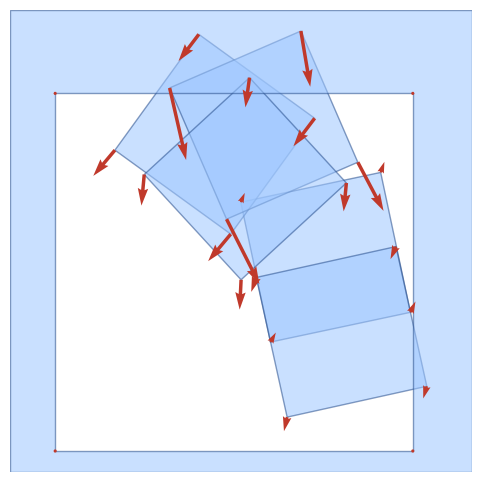

In [2]:
packing = pp.Model(N = 5, n = 4, seed = 42)
# The default if a seed isn't specified is to generate a random seed
packing.generateEquilateralPolygons(phi = 0.8, kappa = 4.0)
# Notice that phi = 1.0 is going to be too large so we'll get 
# overlapping squares no matter what.
packing.setMonoPerimeter() # make all the squares equal in size
# We then set our fixed boundary conditions
vertices = np.array([[0, 0], [0, 1], [1, 1], [1, 0]])
packing.addShape(vertices)
packing.pinVertices(np.arange(packing.getNumVertices())[-4:])
packing.setBoundaryConditions("fixed")
# We add some spring constants:
packing.setConstraints()
# We mollify
packing.setModelType("sharp")
#packing.setSoftDepth(fraction = 1e-2)
packing.initForceEnergy()
packing.calcForceEnergy()
packing.draw(forces = packing.getForces())

Now we can try minimizing this with FIRE. Let's start with 10,000 steps and show a progress bar

FIRE (constrained):   0%|          | 0/10000 [00:00<?, ?it/s]

This was after 1127 steps.


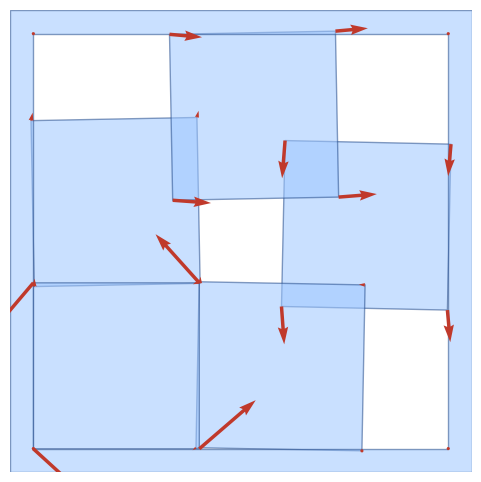

In [4]:
steps = packing.minimizeFIRE(maxSteps = 10_000, fThreshold = 1e-3, progressBar = True)
packing.draw(forces = packing.getForces())
print("This was after " + str(steps) + " steps.")

FIRE (constrained):   0%|          | 0/1000 [00:00<?, ?it/s]

This was after 99 steps.


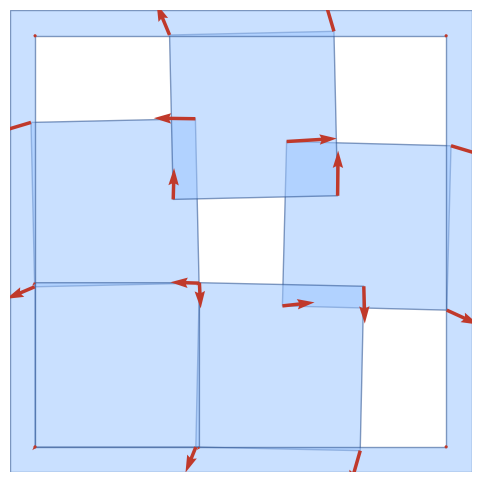

In [5]:
packing.setModelType("softDepth")
packing.setSoftDepth(fraction = 0.01)
steps = packing.minimizeFIRE(maxSteps = 1_000, fThreshold = 1e-3, progressBar = True)
packing.draw(forces = packing.getForces())
print("This was after " + str(steps) + " steps.")

From here we can minimize with softDepth to polish

In [ ]:
packing.minimizeCG(maxSteps = 1_000, fThreshold = 1e-9)
packing.draw(forces = packing.getForces())
print("The maximum unbalanced force is " + str(packing.getMaxUnbalancedForce()))